In [7]:
from data.dataset import FilteredHiRISEDataset, HiRISEDataset
import pandas as pd
import os, time 
from pathlib import Path

project_root = str(Path.cwd())
project_root


'd:\\Imperial\\IRP\\HiRISE_diffusion'

In [8]:
dr = pd.read_csv(project_root + '\\data\\files\\data_record_bin12.csv')
allowed_sets = [19645, 7292, 7293, 14774]  # observations present in data/files/npy_files_b12

dataset = FilteredHiRISEDataset(transform=None, data_record=dr, meta_cols=['Binning', 'TDI'], sweep=False, allowed_sets=allowed_sets)

start_time = time.time()
print(f"Dataset initialisation time: {time.time() - start_time:.2f} seconds")

Filtered dataset:
	Observations: 3
	Sets: 4
	Images: 20
	Proportion of sets: 0.02%

Dataset initialisation time: 0.00 seconds


In [13]:
sample = dataset[1]
print(sample.keys())

dict_keys(['x_band', 'x_neigh', 'x_meta', 'y', 'stats', 'chan_spec_band', 'chan_spec_neigh', 'meta_spec', 'obs_id', 'set_name', 'date'])


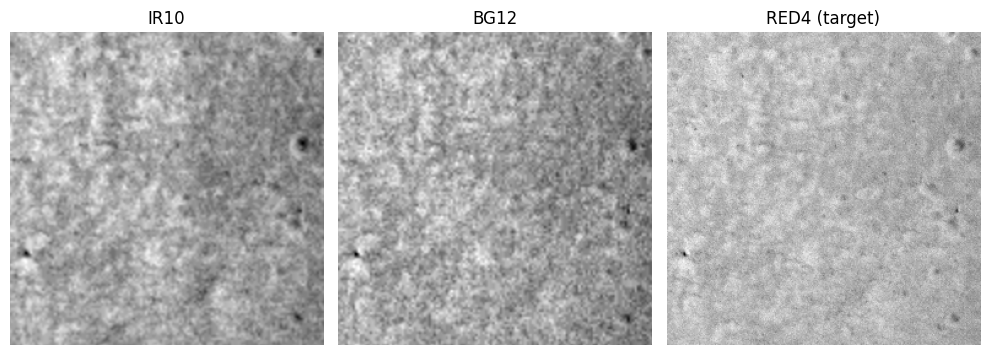

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(sample['x_band'][0].numpy(), cmap='gray')
axs[0].set_title("IR10")
axs[0].axis('off')
axs[1].imshow(sample['x_band'][1].numpy(), cmap='gray')
axs[1].set_title("BG12")
axs[1].axis('off')
axs[2].imshow(sample['y'][0].numpy(), cmap='gray')
axs[2].set_title("RED4 (target)")
axs[2].axis('off')
plt.tight_layout()
plt.show()